# Probabilistic Methods Project: Markov Chains for Weather Prediction

# Obtaining the dataset: loading and preprocessing

In [169]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [170]:
# Download latest version
path = kagglehub.dataset_download("petalme/seattle-weather-prediction-dataset")

print("Path to dataset files:", path)

Path to dataset files: /home/rs/.cache/kagglehub/datasets/petalme/seattle-weather-prediction-dataset/versions/1


In [171]:
# Load dataset CSV into dataframe
csv_path = os.path.join(path, "seattle-weather.csv")

df = pd.read_csv(csv_path)

print(df.head())

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


As we can observe, we have some features, but since we are going to do Markov Chains, we are only interested in the weather lable. Let's see the different categories we can find in this dataset.

In [172]:
df["weather"].unique()

array(['drizzle', 'rain', 'sun', 'snow', 'fog'], dtype=object)

To simplify the problem, we are going to consider drizzle (that is, little rain) as rain.

In [173]:
df["weather"] = df["weather"].replace("drizzle", "rain")

So we have now four different labels:

In [174]:
df["weather"].unique()

array(['rain', 'sun', 'snow', 'fog'], dtype=object)

As we are only interested in the weather labels, we can get rid of the others features.

In [175]:
df = df.drop(["precipitation", "temp_max", "temp_min", "wind"], axis=1)

In [176]:
df

,date,weather
0,2012-01-01,rain
1,2012-01-02,rain
2,2012-01-03,rain
3,2012-01-04,rain
4,2012-01-05,rain
...,...,...
1456,2015-12-27,rain
1457,2015-12-28,rain
1458,2015-12-29,fog
1459,2015-12-30,sun


In [177]:
for i in range(len(df)):
    df.iloc[i, df.columns.get_loc('date')] = i 
print(df)

      date weather
0        0    rain
1        1    rain
2        2    rain
3        3    rain
4        4    rain
...    ...     ...
1456  1456    rain
1457  1457    rain
1458  1458     fog
1459  1459     sun
1460  1460     sun

[1461 rows x 2 columns]


# Obtaining conditional probabilities
We have four possible states: rain, sun, snow, and fog. So the possible combinations are the following:

- rain → rain, rain → sun, rain → snow, rain → fog
- sun → rain, sun → sun, sun → snow, sun → fog
- snow → rain, snow → sun, snow → snow, snow → fog
- fog → rain, fog → sun, fog → snow, fog → fog

Now, we need to obtain a list of tuples, where each tuple have a state and its corresponding future state. With this list, we can compute the conditional probabilites for the transition matrix.

In [178]:
days = []
for i in range(len(df)):
    days.append((df.iloc[i]['date'], df.iloc[i]['weather']))
print(days)

consecutive_days = []
for i in range(len(df)-1): # we do not count the last day
    consecutive_days.append((df.iloc[i]['weather'], df.iloc[i+1]['weather']))
print(consecutive_days)
print(len(consecutive_days))

[(0, 'rain'), (1, 'rain'), (2, 'rain'), (3, 'rain'), (4, 'rain'), (5, 'rain'), (6, 'rain'), (7, 'sun'), (8, 'rain'), (9, 'rain'), (10, 'sun'), (11, 'sun'), (12, 'sun'), (13, 'snow'), (14, 'snow'), (15, 'snow'), (16, 'snow'), (17, 'snow'), (18, 'snow'), (19, 'snow'), (20, 'rain'), (21, 'rain'), (22, 'rain'), (23, 'rain'), (24, 'rain'), (25, 'rain'), (26, 'rain'), (27, 'rain'), (28, 'rain'), (29, 'rain'), (30, 'rain'), (31, 'rain'), (32, 'sun'), (33, 'sun'), (34, 'sun'), (35, 'sun'), (36, 'sun'), (37, 'rain'), (38, 'rain'), (39, 'rain'), (40, 'rain'), (41, 'rain'), (42, 'rain'), (43, 'rain'), (44, 'rain'), (45, 'rain'), (46, 'rain'), (47, 'rain'), (48, 'rain'), (49, 'sun'), (50, 'rain'), (51, 'rain'), (52, 'rain'), (53, 'sun'), (54, 'rain'), (55, 'rain'), (56, 'snow'), (57, 'sun'), (58, 'snow'), (59, 'snow'), (60, 'sun'), (61, 'rain'), (62, 'sun'), (63, 'rain'), (64, 'rain'), (65, 'snow'), (66, 'sun'), (67, 'sun'), (68, 'rain'), (69, 'rain'), (70, 'rain'), (71, 'snow'), (72, 'snow'), (73

In [179]:
total_rain = 0
total_sun = 0
total_snow = 0
total_fog = 0

for i in consecutive_days:
    if i[0] == "rain":
        total_rain += 1
    elif i[0] == "sun":
        total_sun += 1
    elif i[0] == "snow":
        total_snow += 1
    else:
        total_fog += 1
print(total_rain+total_sun+total_snow+total_fog)

1460


In order to compute the conditional probability of each state transtition, we must first count the number of occurences of each state transition in the data. To do so, we made a naive long code snippet which is included for explainability, although not executed, and then the final version which is harder to understand but more concise.

```python
# long naive version
rain_to_rain = rain_to_sun = rain_to_snow = rain_to_fog = 0
sun_to_rain = sun_to_sun = sun_to_snow = sun_to_fog = 0
snow_to_rain = snow_to_sun = snow_to_snow = snow_to_fog = 0
fog_to_rain = fog_to_sun = fog_to_snow = fog_to_fog = 0

for i in consecutive_days:
    if i == ('rain', 'rain'):
        rain_to_rain += 1
    elif i == ('rain', 'sun'):
        rain_to_sun += 1
    elif i == ('rain', 'snow'):
        rain_to_snow += 1
    elif i == ('rain', 'fog'):
        rain_to_fog += 1

    elif i == ('sun', 'rain'):
        sun_to_rain += 1
    elif i == ('sun', 'sun'):
        sun_to_sun += 1
    elif i == ('sun', 'snow'):
        sun_to_snow += 1
    elif i == ('sun', 'fog'):
        sun_to_fog += 1

    elif i == ('snow', 'rain'):
        snow_to_rain += 1
    elif i == ('snow', 'sun'):
        snow_to_sun += 1
    elif i == ('snow', 'snow'):
        snow_to_snow += 1
    elif i == ('snow', 'fog'):
        snow_to_fog += 1

    elif i == ('fog', 'rain'):
        fog_to_rain += 1
    elif i == ('fog', 'sun'):
        fog_to_sun += 1
    elif i == ('fog', 'snow'):
        fog_to_snow += 1
    elif i == ('fog', 'fog'):
        fog_to_fog += 1

print(rain_to_rain, rain_to_sun, rain_to_snow, rain_to_fog)
print(sun_to_rain, sun_to_sun, sun_to_snow, sun_to_fog)
print(snow_to_rain, snow_to_sun, snow_to_snow, snow_to_fog)
print(fog_to_rain, fog_to_sun, fog_to_snow,  fog_to_fog)
```
With its respective output:
```python
485 159 11 39
164 436 5 34
11 5 10 0
33 40 0 28
```

And this is the final version:

In [180]:
# short version
states = ['rain', 'sun', 'snow', 'fog']
transitions = {}
for i in consecutive_days:
    for j in states:
        for k in states:
            if i == (j, k):
                key = f'{j}_to_{k}'
                if key not in transitions:
                    transitions[key] = 0
                transitions[key] += 1
print(len(transitions))
print(transitions)

14
{'rain_to_rain': 485, 'rain_to_sun': 159, 'sun_to_rain': 164, 'sun_to_sun': 436, 'sun_to_snow': 5, 'snow_to_snow': 10, 'snow_to_rain': 11, 'rain_to_snow': 11, 'snow_to_sun': 5, 'rain_to_fog': 39, 'fog_to_rain': 33, 'sun_to_fog': 34, 'fog_to_sun': 40, 'fog_to_fog': 28}


In [181]:
# Normalize to obtain conditional probabilities
for i in transitions.keys():
    if i[0] == 'r':     #rain
        transitions[i] = transitions[i] / total_rain
    elif i[1] == 'u':   #sun
        transitions[i] = transitions[i] / total_sun
    elif i[1] == 'n':   #snow
        transitions[i] = transitions[i] / total_snow
    elif i[0] == 'f':   #fog
        transitions[i] = transitions[i] / total_fog

The following are the conditional probabilities for going from a givent event $A$ to an event $B$, $P(B|A) \rightarrow$ "A_to_B", e.g., `"rain_to_sun"`. One may notice that the following collection of tupples only account for 14 out of 16 possible state transitions. This is because they are added dynamically in the previous code blocks to the transitions dictionary when they are encountered in the real sequence. Since some transitions never occur, they are not added to the dictionary and will be manually appended later.

In [182]:
for i in transitions.items():
    print(i)

('rain_to_rain', 0.6988472622478387)
('rain_to_sun', 0.22910662824207492)
('sun_to_rain', 0.2566510172143975)
('sun_to_sun', 0.6823161189358372)
('sun_to_snow', 0.00782472613458529)
('snow_to_snow', 0.38461538461538464)
('snow_to_rain', 0.4230769230769231)
('rain_to_snow', 0.01585014409221902)
('snow_to_sun', 0.19230769230769232)
('rain_to_fog', 0.056195965417867436)
('fog_to_rain', 0.32673267326732675)
('sun_to_fog', 0.053208137715179966)
('fog_to_sun', 0.39603960396039606)
('fog_to_fog', 0.27722772277227725)


We then run a check, to verify that all probabilities add up to 1. Due to the way Python handles the precision of numerical computations, sometimes probabilities add up to 0.999999..., instead of 1.0.

In [183]:
# check if they sum to 1
P_rain = 0
P_sun = 0
P_snow = 0
P_fog = 0
for i in transitions.keys():
    if i[0] == 'r':     #rain
        P_rain += transitions[i]
    elif i[1] == 'u':   #sun
        P_sun += transitions[i]
    elif i[1] == 'n':   #snow
        P_snow += transitions[i]
    elif i[0] == 'f':   #fog
        P_fog += transitions[i]
print(P_rain, P_sun, P_snow, P_fog) 

1.0 1.0 1.0 1.0


In this next step, missing state transitions (i.e., the ones that never occur) are added to the transitions dictionary. Such dictionary is then used to construct the transition matrix for the sequence in our ground truth dataset.

In [184]:
# Transition matrix
# Adding missing states
transitions['snow_to_fog'] = 0
transitions['fog_to_snow'] = 0
# Row is current state and column is future state
T = [
    [transitions['rain_to_rain'], transitions['rain_to_sun'], transitions['rain_to_snow'], transitions['rain_to_fog']],
    [transitions['sun_to_rain'],  transitions['sun_to_sun'],  transitions['sun_to_snow'],  transitions['sun_to_fog']],
    [transitions['snow_to_rain'], transitions['snow_to_sun'], transitions['snow_to_snow'], transitions['snow_to_fog']],
    [transitions['fog_to_rain'],  transitions['fog_to_sun'],  transitions['fog_to_snow'],  transitions['fog_to_fog']]
]
T = np.array(T)
print(T)

[[0.69884726 0.22910663 0.01585014 0.05619597]
 [0.25665102 0.68231612 0.00782473 0.05320814]
 [0.42307692 0.19230769 0.38461538 0.        ]
 [0.32673267 0.3960396  0.         0.27722772]]


# Simulation


In [185]:
import random

states = ['rain', 'sun', 'snow', 'fog']
# Starting from sun, for example:
initial_state = 'rain'
chain = [initial_state]
weights_rain = T[0]
weights_sun = T[1]
weights_snow = T[2]
weights_fog = T[3]

# cambiar numero de iteraciones para ver como varian las probabilidades condicionadas
# obtenidas en la simulacion (y comparar cada caso con las probabilidades reales)
iterations = 100000

for i in range(iterations):
    current_state = chain[-1]
    if current_state == 'rain':
        w = weights_rain
    elif current_state == 'sun':
        w = weights_sun
    if current_state == 'snow':
        w = weights_snow
    if current_state == 'fog':
        w = weights_fog
        
    future_state = random.choices(states, weights = w, k=1)[0]
    chain.append(future_state)

#print(chain) # print full chain for debuging

In [186]:
counts = {'rain': 0, 'sun': 0, 'snow': 0, 'fog': 0}

for state in chain:
    if state in counts:
        counts[state] += 1

# If the chain has an odd number of states, we don't need to count the 
# last one, since it doesn't form a transition with the next state,
# because there isn't one
if len(chain) % 2 != 0:
    last = chain[-1]
    if last in counts:
        counts[last] -= 1
print(counts)

{'rain': 47626, 'sun': 43710, 'snow': 1729, 'fog': 6935}


In [187]:
consecutive_days = []
for i in range(iterations):
    consecutive_days.append((chain[i], chain[i+1]))
print(consecutive_days)

[('rain', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'sun'), ('sun', 'sun'), ('sun', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'sun'), ('sun', 'rain'), ('rain', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'rain'), ('rain', 'sun'), ('sun', 'rain'), ('rain', 'sun'), ('sun', 'sun'), ('sun', 'rain'), ('rain', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'snow'), ('snow', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'rain'), ('rain', 'sun'), ('sun', 'sun'), ('sun', 'sun'), ('sun', 'rain'), ('rain', 'rain'), ('rain', 'rain'), (

In [188]:
states = ['rain', 'sun', 'snow', 'fog']
transitions = {}
for i in consecutive_days:
    for j in states:
        for k in states:
            if i == (j, k):
                key = f'{j}_to_{k}'
                if key not in transitions:
                    transitions[key] = 0
                transitions[key] += 1
print(len(transitions))
print(transitions)

14
{'rain_to_sun': 10828, 'sun_to_sun': 29916, 'sun_to_rain': 11223, 'rain_to_rain': 33404, 'sun_to_snow': 335, 'snow_to_sun': 308, 'sun_to_fog': 2236, 'fog_to_sun': 2659, 'rain_to_fog': 2677, 'fog_to_rain': 2254, 'fog_to_fog': 2022, 'rain_to_snow': 717, 'snow_to_rain': 744, 'snow_to_snow': 677}


In [189]:
# Normalize to obtain conditional probabilities
for i in transitions.keys():
    if i[0] == 'r':     #rain
        transitions[i] = transitions[i] / counts['rain']
    elif i[1] == 'u':   #sun
        transitions[i] = transitions[i] / counts['sun']
    elif i[1] == 'n':   #snow
        transitions[i] = transitions[i] / counts['snow']
    elif i[0] == 'f':   #fog
        transitions[i] = transitions[i] / counts['fog']

In [190]:
for i in transitions.items():
    print(i)

('rain_to_sun', 0.22735480619829504)
('sun_to_sun', 0.6844200411805079)
('sun_to_rain', 0.2567604667124228)
('rain_to_rain', 0.7013815982866501)
('sun_to_snow', 0.00766415008007321)
('snow_to_sun', 0.17813765182186234)
('sun_to_fog', 0.05115534202699611)
('fog_to_sun', 0.38341744772891134)
('rain_to_fog', 0.05620879351614664)
('fog_to_rain', 0.32501802451333817)
('fog_to_fog', 0.29156452775775055)
('rain_to_snow', 0.015054801998908159)
('snow_to_rain', 0.43030653556969345)
('snow_to_snow', 0.3915558126084442)


In [191]:
# check if they sum to 1
P_rain = 0
P_sun = 0
P_snow = 0
P_fog = 0
for i in transitions.keys():
    if i[0] == 'r':     #rain
        P_rain += transitions[i]
    elif i[1] == 'u':   #sun
        P_sun += transitions[i]
    elif i[1] == 'n':   #snow
        P_snow += transitions[i]
    elif i[0] == 'f':   #fog
        P_fog += transitions[i]
print(P_rain, P_sun, P_snow, P_fog) 

1.0 1.0 1.0 1.0


We use this code to automatically populate the transition matrix computed from the simulation. Missing values for state transitions that do not occur are set to zero.

In [192]:

# Using previously declared: states = ['rain', 'sun', 'snow', 'fog']

transition_keys = [(from_state, to_state) for from_state in states for to_state in states]

# Fill missing transitions with 0
transitions = {f"{from_state}_to_{to_state}": transitions.get(f"{from_state}_to_{to_state}", 0.0)
               for from_state, to_state in transition_keys}

# Create the transition matrix
T_sim = [
    [transitions[f'{from_state}_to_{to_state}'] for to_state in states]
    for from_state in states
]
print(T_sim)
print(f"Transition matrix from {iterations} iteration simulation:\n\n", np.array(T_sim))

[[0.7013815982866501, 0.22735480619829504, 0.015054801998908159, 0.05620879351614664], [0.2567604667124228, 0.6844200411805079, 0.00766415008007321, 0.05115534202699611], [0.43030653556969345, 0.17813765182186234, 0.3915558126084442, 0.0], [0.32501802451333817, 0.38341744772891134, 0.0, 0.29156452775775055]]
Transition matrix from 100000 iteration simulation:

 [[0.7013816  0.22735481 0.0150548  0.05620879]
 [0.25676047 0.68442004 0.00766415 0.05115534]
 [0.43030654 0.17813765 0.39155581 0.        ]
 [0.32501802 0.38341745 0.         0.29156453]]


# Analysing results

## Transition matrix from real data
The matrix of conditional probabilities for each state transition in our dataset is:

In [193]:
import numpy as np
print(np.array(T))

[[0.69884726 0.22910663 0.01585014 0.05619597]
 [0.25665102 0.68231612 0.00782473 0.05320814]
 [0.42307692 0.19230769 0.38461538 0.        ]
 [0.32673267 0.3960396  0.         0.27722772]]


Conditional probabilities can also be rendered as a graph:

(probabilities are rounded)

In [ ]:
from IPython.display import display, HTML, Javascript

def render_mermaid(code):
  display(HTML(f"""
  <div class="mermaid">
  {code}
  </div>
  <script type="module">
    import mermaid from "https://cdn.jsdelivr.net/npm/mermaid@10/dist/mermaid.esm.min.mjs";
    mermaid.initialize({{ startOnLoad: true }});
    mermaid.run();
  </script>
  """))

render_mermaid("""
graph LR
  A[Rain]:::rain -->|70%| A
  A -->|23%| B(Sun)
  B -->|68%| B
  B -->|26%| A
  C(Snow):::snow -->|38%| C
  C -->|42%| A
  D(Fog):::fog -->|28%| D
  D -->|40%| B
  D -->|33%| A

  classDef rain fill:#4A90E2,color:white;
  classDef sun fill:#FFD700,color:black;
  classDef snow fill:#B0E0E6,color:black;
  classDef fog fill:#A9A9A9,color:white;

  class A rain;
  class B sun;
  class C snow;
  class D fog;
""")


## Comparison with simulated transition matrices

Using the previously introduced simulator, we can generate transition matrices for an arbitrary number of 

In [195]:
T_simulations = {
  25: [[0.75, 0.1875, 0.0, 0.0625], [0.2222222222222222, 0.6666666666666666, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0], [1.0, 0.0, 0.0, 0.0]],
  50: [[0.7272727272727273, 0.2727272727272727, 0.0, 0.0], [0.2222222222222222, 0.6666666666666666, 0.0, 0.1111111111111111], [0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0]],
  100: [[0.52, 0.36, 0.08, 0.04], [0.12307692307692308, 0.8, 0.0, 0.07692307692307693], [0.5, 0.0, 0.5, 0.0], [0.16666666666666666, 0.8333333333333334, 0.0, 0.0]],
  250: [[0.7101449275362319, 0.2028985507246377, 0.028985507246376812, 0.057971014492753624], [0.34146341463414637, 0.6097560975609756, 0.012195121951219513, 0.036585365853658534], [0.3076923076923077, 0.07692307692307693, 0.6153846153846154, 0.0], [0.4117647058823529, 0.23529411764705882, 0.0, 0.35294117647058826]],
  500: [[0.6939655172413793, 0.22844827586206898, 0.008620689655172414, 0.06896551724137931], [0.2409090909090909, 0.6954545454545454, 0.00909090909090909, 0.05454545454545454], [0.6, 0.2, 0.2, 0.0], [0.32558139534883723, 0.32558139534883723, 0.0, 0.3488372093023256]],
  1000: [[0.7010752688172043, 0.23655913978494625, 0.010752688172043012, 0.05161290322580645], [0.2555066079295154, 0.6850220264317181, 0.0022026431718061676, 0.05726872246696035], [0.45454545454545453, 0.09090909090909091, 0.45454545454545453, 0.0], [0.2571428571428571, 0.45714285714285713, 0.0, 0.2857142857142857]],
  2500: [[0.6960461285008237, 0.23640856672158156, 0.016474464579901153, 0.051070840197693576], [0.2796610169491525, 0.6534839924670434, 0.006591337099811676, 0.060263653483992465], [0.34, 0.2, 0.46, 0.0], [0.3103448275862069, 0.41379310344827586, 0.0, 0.27586206896551724]],
  5000: [[0.7022149302707137, 0.2276456111566858, 0.016406890894175553, 0.053732567678424936], [0.2681797128300139, 0.6767021769337657, 0.006484483557202408, 0.04863362667901806], [0.38144329896907214, 0.17525773195876287, 0.44329896907216493, 0.0], [0.3562091503267974, 0.4150326797385621, 0.0, 0.22875816993464052]],
  10000: [[0.6976694915254237, 0.2305084745762712, 0.012711864406779662, 0.05911016949152542], [0.2559510315121288, 0.6835184765359329, 0.00838812060757198, 0.052142371344366355], [0.4358974358974359, 0.1858974358974359, 0.3782051282051282, 0.0], [0.3225806451612903, 0.391304347826087, 0.0, 0.2861150070126227]],
  25000: [[0.6978086316493811, 0.22791903646704584, 0.016142522582803614, 0.05812980930076949], [0.259385981135565, 0.6781024597743666, 0.010356944701313113, 0.052154614388755315], [0.4139344262295082, 0.21106557377049182, 0.375, 0.0], [0.3478760045924225, 0.3748564867967853, 0.0, 0.2772675086107922]],
  50000: [[0.704653888005357, 0.22214781953628526, 0.015192098434753495, 0.058006194023604254], [0.2554663714364794, 0.6822123812159794, 0.008026570716855799, 0.05429467663068549], [0.43431952662721895, 0.20118343195266272, 0.36449704142011835, 0.0], [0.3215182807703042, 0.3938040747976556, 0.0, 0.2846776444320402]],
  100000: [[0.6993491585399246, 0.22981654274701435, 0.015312677717631696, 0.055521620995429365], [0.2570639521614096, 0.6816314420048386, 0.008832793171132515, 0.05247181266261925], [0.42006615214994486, 0.1940463065049614, 0.38588754134509373, 0.0], [0.3260333575054387, 0.3897026831036983, 0.0, 0.28426395939086296]],
}

### Error heatmaps
The error heatmaps visualize the absolute element-wise differences between the reference matrix $T$ and each simulated matrix $T_n$ (where $n$ is the number of simulations) across increasing numbers of iterations. A trend emerges: as $n$ increases, the magnitude of the errors decreases, and the reference and simulation matrices converge.

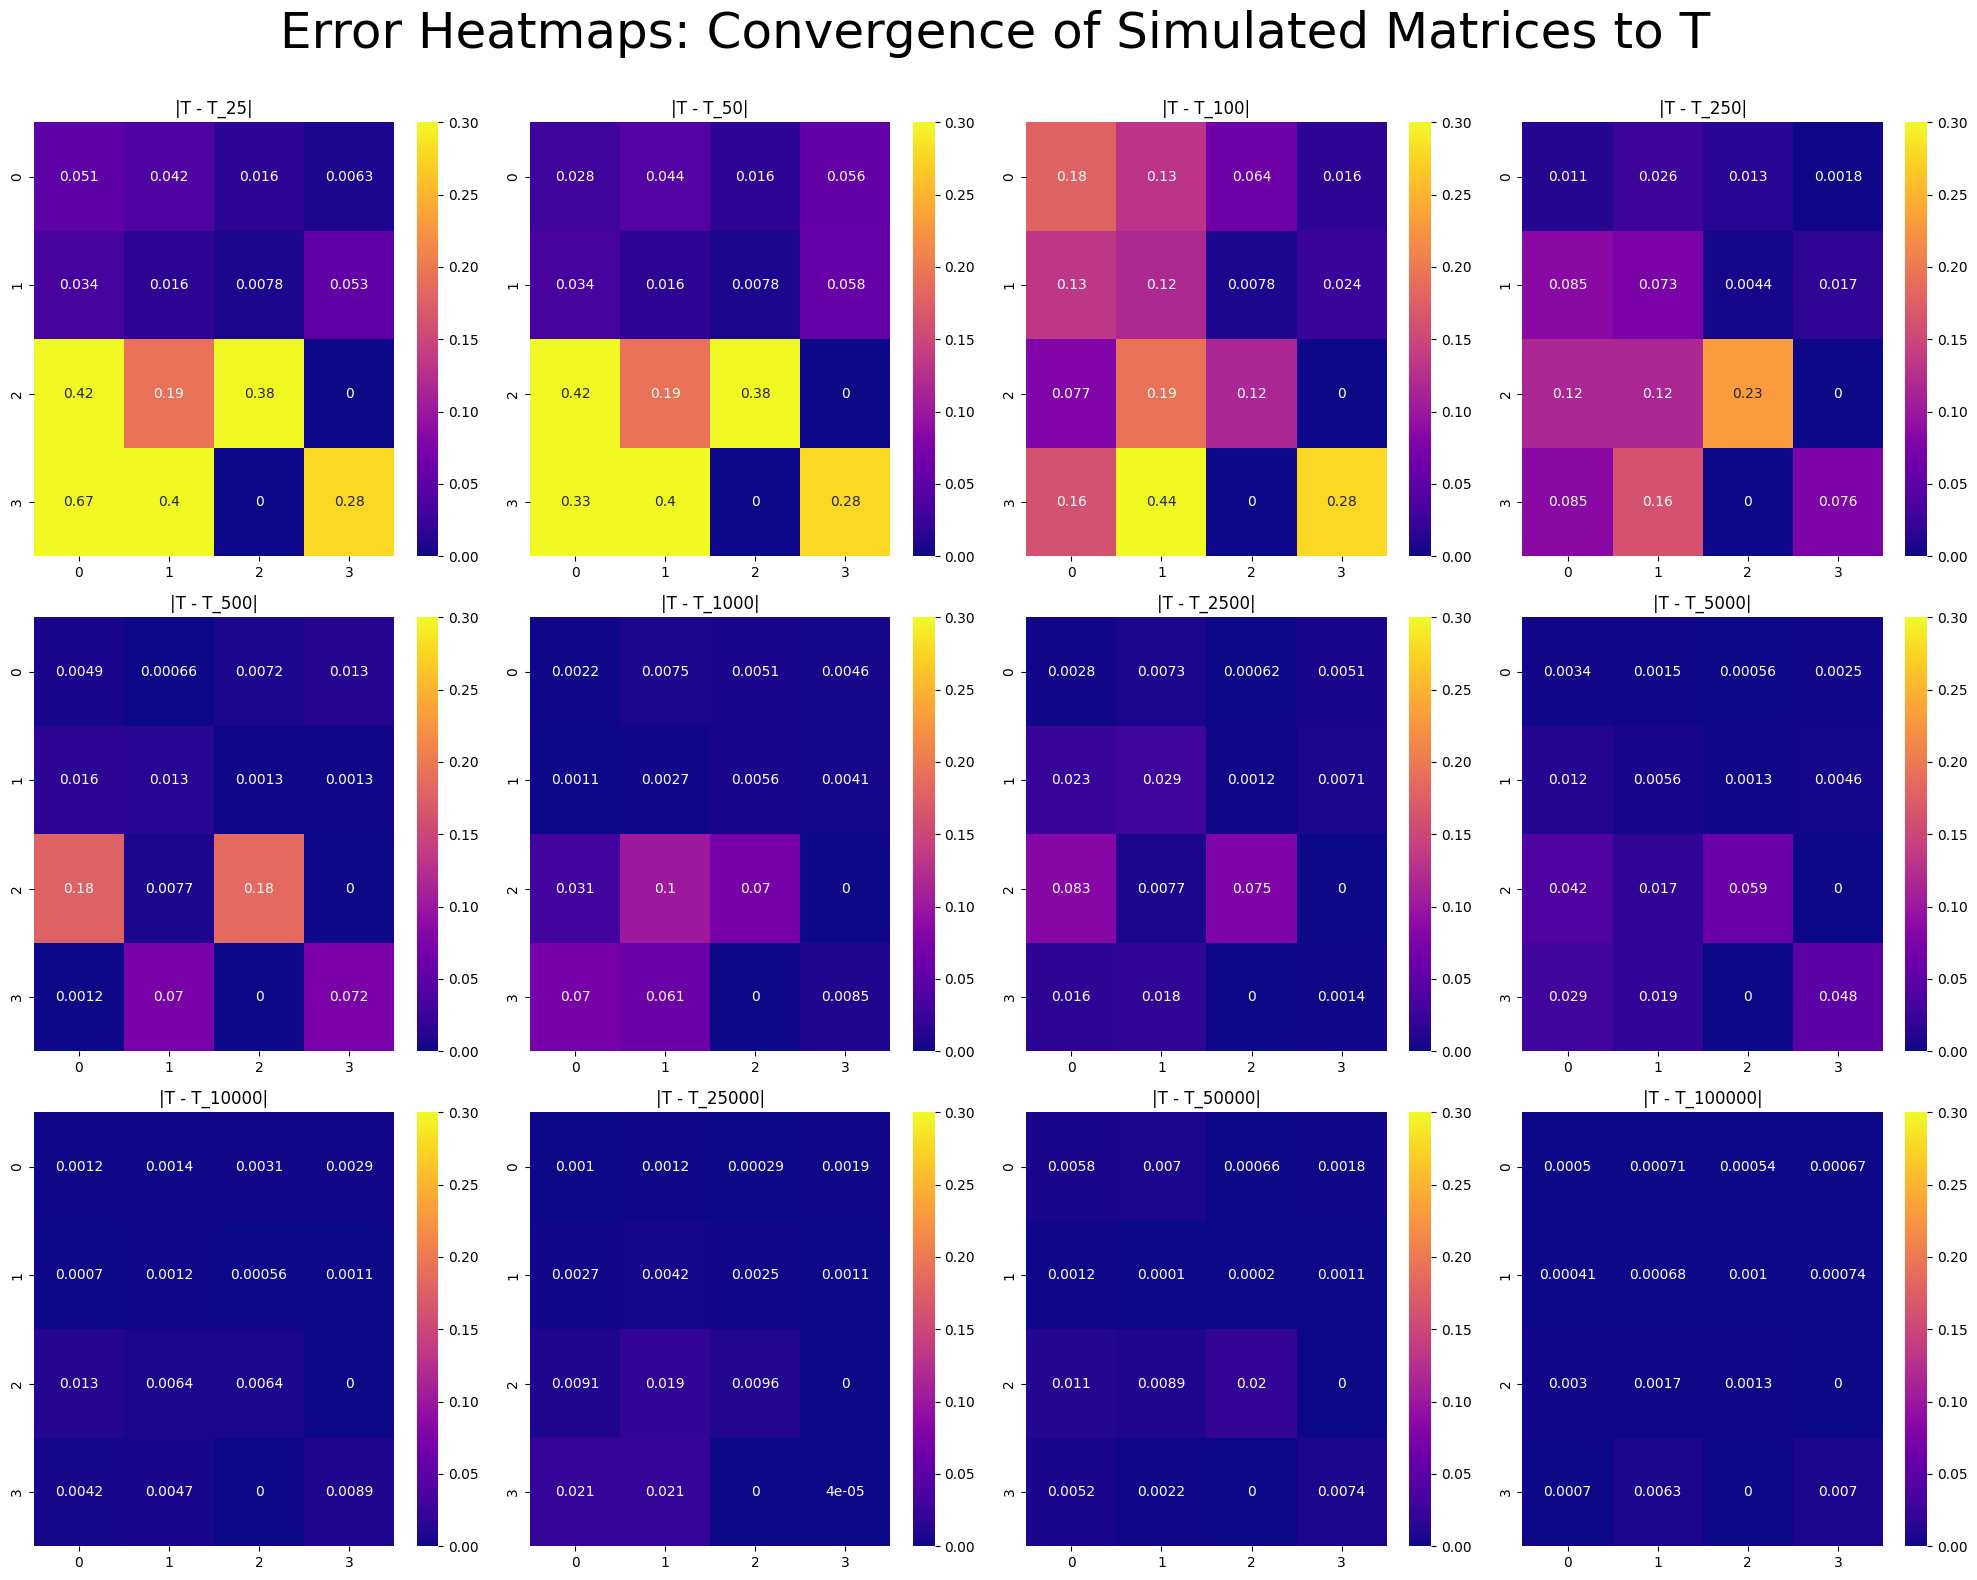

In [196]:
# Set up the subplot grid (adjust size if more/less subplots are needed)
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

# Plot each error heatmap
for i, (n, T_n) in enumerate(sorted(T_simulations.items())):
    T_n_array = np.array(T_n)  # Convert list of lists to NumPy array
    error_matrix = np.abs(T - T_n_array)
    
    ax = axes[i]
    sns.heatmap(error_matrix, annot=True, cmap="plasma", vmin=0, vmax=0.3, ax=ax)
    ax.set_title(f'|T - T_{n}|')

# Clean layout
plt.tight_layout()
plt.suptitle("Error Heatmaps: Convergence of Simulated Matrices to T", fontsize=36, y=1.05)
#plt.savefig(f"error_heatmaps.png")
plt.show()

Auxiliar code to save all plots in a file:
```python
# Save each matrix plot to a standalone file
for i, (n, T_n) in enumerate(sorted(T_simulations.items())):
    T_n_array = np.array(T_n)
    error_matrix = np.abs(T - T_n_array)

    plt.figure(figsize=(6, 5))
    sns.heatmap(error_matrix, annot=True, cmap="plasma", vmin=0, vmax=0.3)
    plt.title(f'|T - T_{n}|')
    plt.tight_layout()
    plt.savefig(f"error_heatmap_{n}.png")  # Save each figure separately
    plt.close()  # Close the figure to free memory
```

### Frobenius norm
The Frobenius norm is a way to measure the overall difference between two matrices by summing the squares of the differences between corresponding elements, then taking the square root. It’s similar to computing the Euclidean distance but extended to matrices.

In the context of Markov models or simulations, we use the Frobenius norm to quantify how close a simulated transition matrix is to the original matrix. This gives us a single number that reflects the total error, making it useful for tracking convergence and comparing accuracy across different simulation sizes.

When comparing two matrices $A$ and $B$, the Frobenius norm of their difference measures the total squared error:

$$
\|A - B\|_F = \sqrt{ \sum_{i=1}^{m} \sum_{j=1}^{n} (a_{ij} - b_{ij})^2 }
$$

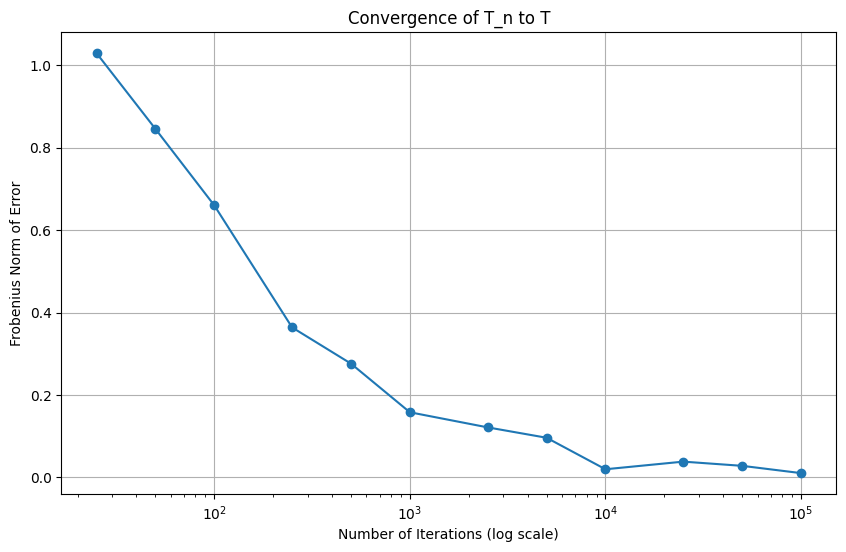

In [197]:
frobenius_errors = []
iteration_counts = []

# Compute Frobenius norms
for n, T_n in sorted(T_simulations.items()):
    T_n_array = np.array(T_n)  # Convert list to NumPy array
    error = np.linalg.norm(T - T_n_array, ord='fro')  # Frobenius norm
    frobenius_errors.append(error)
    iteration_counts.append(n)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(iteration_counts, frobenius_errors, marker='o')
plt.xscale('log')
plt.xlabel('Number of Iterations (log scale)')
plt.ylabel('Frobenius Norm of Error')
plt.title('Convergence of T_n to T')
plt.grid(True)
plt.show()